<a href="https://colab.research.google.com/github/Kohei-200/math/blob/main/simulation/Audio_Effects1_LTI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Linear Time-Invariance

#### Examples

`Linear` but `not TI`



- AM modulation ($y[n] = x[n]cos(2pi\omega_cn$))
- Time Stretch ($y(t) = x(\alpha t$))
- DTFT

`not Linear` and `not TI`

- Envelope Detection ($y[n] = |x[n]|^2 * h[n]$)
- Clipping $y[n] = \begin{cases}
x[n], x[n] \le M \\
0, otherwise
\end{cases}$

#### **Linear and TI**
- Second Derivative ($y(t) = \frac{d^2}{dt^2}x(t)$)

#### Linearity

$$\mathcal{H}\{ax_1 + bx_2\} = a\mathcal{H}\{x_1\} + b\mathcal{H}\{x_2\}$$
scaling the input scales the output by the same amount, and response to a sum of signals equals the sum of the responses.
#### Time-invariance
$$\mathcal{H}\{x[n - n_0]\} = y[n-n_0]$$
delaying the input only delayes the output by the same amount.

### LTI effects (this note explores)
- EQ (non-dynamic)
- Active crossover
- Delay/echo (static)
- Reverb
### non-LTI effects (not explored here)
`Nonlinear`
- Distortion / overdrive / saturation / clipping
- Compressor / limiter / gate
- Bitcrushing

`Time-varying`
- Chorus / flanger
- Phaser
- Vibrato
- (Auto-)Wah / envelope filter
- Pitch shift / time-stretch
- De-esser
- Sidechain (noise gates)

### Quick Conclusion
LTI effects do not take parameters from the signal itself and from `n`.

### Audio Sources / Plot Functions

In [1]:
import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
import scipy

In [2]:
# audio sample MTG sms-tools
!git clone https://github.com/MTG/sms-tools-materials.git

fatal: destination path 'sms-tools-materials' already exists and is not an empty directory.


In [3]:
# Impulse response
impulse_response =  "/content/sms-tools-materials/sounds/impulse-response.wav"

# White noise
sr = 48000
sf.write("white_noise.wav",  np.random.uniform(low=-0.2, high=0.2, size=sr), sr)
white_noise = "white_noise.wav"

# Chirp
dur = 2
N = int(sr*dur)
t = np.arange(N) / sr
sf.write("chirp.wav",  scipy.signal.chirp(t, f0=20, f1=8000, t1=dur, method="linear"), sr)
chirp_lin = "chirp.wav"

# Sine
sine_490 = "/content/sms-tools-materials/sounds/sine-490.wav"


audios = {"impulse_response":impulse_response,
          "white_noise": white_noise,
          "chirp_lin": chirp_lin, "sine_490": sine_490}

plot funcs

In [4]:
def plot_audios(effect_name, audios: dict):

   for name, (audio_path, audio_mod_path) in audios.items():
        x, sr = sf.read(audio_path)
        x_mod, sr_mod = sf.read(audio_mod_path)

        time = np.linspace(0, len(x) / sr, num=len(x))
        time_mod = np.linspace(0, len(x_mod) / sr_mod, num=len(x_mod))

        print(f"{name} — original")
        ipd.display(ipd.Audio(x, rate=sr))
        print(f"{name} — {effect_name}")
        ipd.display(ipd.Audio(x_mod, rate=sr_mod))

        fig, axes = plt.subplots(2, 1, figsize=(5, 3), dpi=100, sharex=True)

        axes[0].set_title(f"{name} (original)")
        axes[0].plot(time, x, linewidth=0.5)

        axes[1].set_title(f"{name} ({effect_name})")
        axes[1].plot(time_mod, x_mod, linewidth=0.5)

        axes[1].set_xlabel("Time (s)")
        plt.tight_layout()
        plt.show()

In [5]:
def overlay_spectra(effect_name, audios: dict, scale = "log"):

    for name, (audio_path, audio_mod_path) in audios.items():
        x, sr = sf.read(audio_path)
        x_mod, sr_mod = sf.read(audio_mod_path)

        # FFT magnitude (rfft since audio is real-valued)
        X = np.fft.rfft(x)
        X_mod = np.fft.rfft(x_mod)
        freqs = np.fft.rfftfreq(len(x), d=1/sr)
        freqs_mod = np.fft.rfftfreq(len(x_mod), d=1/sr_mod)

        # magnitude in dB, with a floor to avoid log(0)
        mag_db = 20 * np.log10(np.abs(X) + 1e-12)
        mag_mod_db = 20 * np.log10(np.abs(X_mod) + 1e-12)

        fig, ax = plt.subplots(figsize=(5, 3), dpi=100)
        ax.plot(freqs, mag_db, label="original", alpha=0.7, linewidth=0.7)
        ax.plot(freqs_mod, mag_mod_db, label=f"{effect_name}", alpha=0.7, linewidth=0.7)

        ax.set_title(name)
        ax.set_xlabel("Freq (Hz)")
        ax.set_ylabel("Mag (dB)")
        ax.legend()

        if scale == "log":
            ax.set_xscale("log")
            ax.set_xlim(20, sr/2)
        ax.grid(True, which="both", alpha=0.2)
        plt.tight_layout()
        plt.show()

### EQ

global:
- `sample rate`($f_s$)

params:
- `center freq`($f_0$)
- `quality` ($Q = \frac{f_0}{BW}$ $BW$: Band Width)
- `gain_db`

values:
- `peak/shelf gain` ($A = 10 ^ {\text{gain_db}/40}$
- `angular frequency` ($\omega_0 = 2\pi f_0/f_s$)
- `"damping" factor` ($\alpha = \frac{sin(\omega_0)}{2Q}$)

6 coefficients (order 2 / biquad):
- Zeros: `feedforward (numerator) coefficients` ($b_0, b_1, b_2$)
- Poles: `feedback (denominator) coefficients` ($a_0, a_1, a_2$)

output (normalized, $a_0 = 1$):
- $y[n]=b_0x[n]+b_1x[n−1]+b_2x[n−2]-a_1y[n−1]-a_2y[n−2]$

z-plane:
- $H(z) = \frac{b_0 + b_1z^{-1} + b_2z^{-2}}{1 + a_1z^{-1} + a_2z^{-2}}$

In [6]:
def peaking_EQ_biquad(f0: float, # center frequency, Hz
                      Q: float,  # (bandwidth control)
                      gain_db: float, # boost (+) or cut (-) at f0, in dB
                      fs: float
                      ) -> tuple[np.ndarray, np.ndarray]:
    """
    Return:
    b : np.ndarray, shape (3,) — feedforward coefficients [b0, b1, b2]
    a : np.ndarray, shape (3,) — feedback coefficients [1, a1, a2]
    """
    A      = 10 ** (gain_db / 40)
    omega0 = 2 * np.pi * f0 / fs
    alpha  = np.sin(omega0) / (2 * Q)

    b0 = 1 + alpha*A
    b1 = -2*np.cos(omega0)
    b2 = 1 - alpha*A
    a0 = 1 + alpha/A
    a1 = -2*np.cos(omega0)
    a2 = 1 - alpha/A

    # normalize
    b = np.array([b0, b1, b2]) / a0
    a = np.array([1, a1/a0, a2/a0])

    return b, a

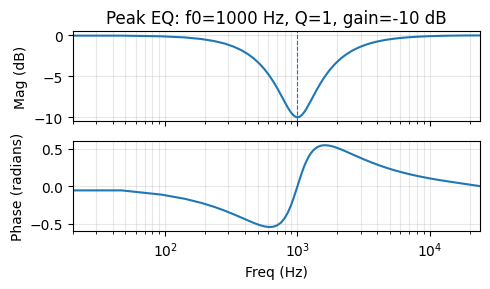

In [7]:
f0, Q, gain_db, fs = 1000, 1, -10, 48000
b, a = peaking_EQ_biquad(f0, Q, gain_db, fs)

w, h = scipy.signal.freqz(b, a, fs=fs)

mag_db = 20 * np.log10(np.abs(h) + 1e-12)
phase = np.angle(h)

fig, axes = plt.subplots(2, 1, figsize=(5, 3), dpi=100, sharex=True)

axes[0].plot(w, mag_db)
axes[0].set_ylabel("Mag (dB)")
axes[0].set_title(f"Peak EQ: f0={f0} Hz, Q={Q}, gain={gain_db} dB")
axes[0].axvline(f0, linestyle="--", linewidth=0.8)
axes[0].set_xscale("log")
axes[0].set_xlim(20, fs/2)
axes[0].grid(True, which="both", alpha=0.3)

axes[1].plot(w, phase)
axes[1].set_ylabel("Phase (radians)")
axes[1].set_xlabel("Freq (Hz)")
axes[1].set_xscale("log")
axes[1].set_xlim(20, fs/2)
axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
def apply_EQ(audios):
    output = {}
    for name, audio in audios.items():
        x, sr = sf.read(audio)

        f0, Q, gain_db = 1000, 1, -10
        b, a = peaking_EQ_biquad(f0, Q, gain_db, sr)
        x_filtered = scipy.signal.lfilter(b, a, x)

        sf.write(f"{name}_EQd.wav", x_filtered, sr)
        output[name] = (audio, f"{name}_EQd.wav")
    return output

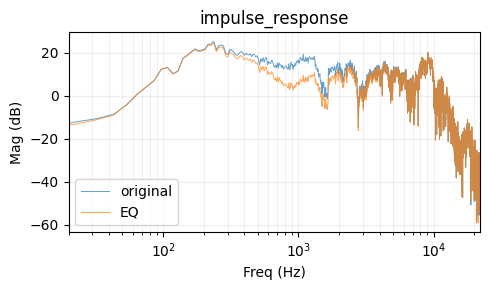

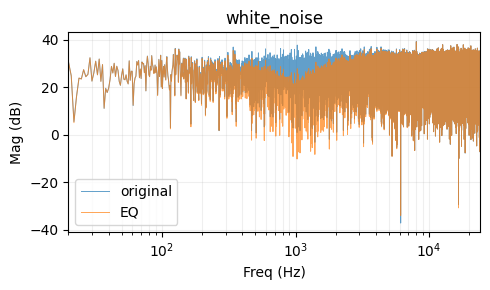

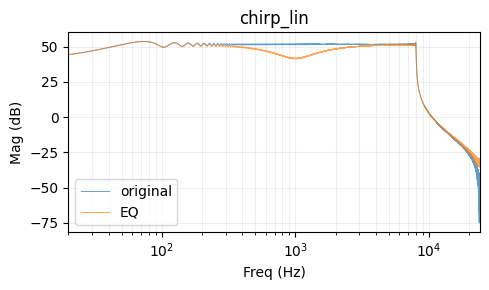

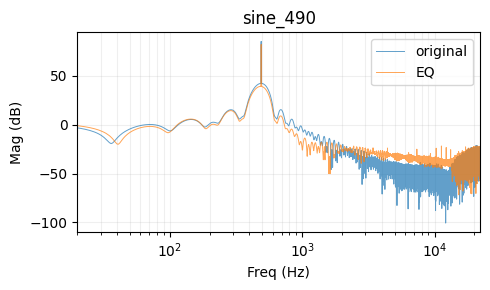

In [9]:
output = apply_EQ(audios)
overlay_spectra("EQ", output)

### Crossover: 2nd-order Butterworth into Linkwitz-Riley 4th order (LR4)

$\omega_0 = 2\pi \frac{f_c}{f_s}$

$\alpha = \frac{sin\omega_0}{2Q}$

Low-pass
- $b_0 = \frac{1-cos\omega_0}{2}, b_1 = 1 - cos\omega_0, b_2 = b_0$
- $a_0 = 1 + \alpha, a_1 = -2cos\omega_0, a_2 = 1-\alpha$

High-pass
- $b_0 = \frac{1+cos\omega_0}{2}, b_1 = - 1 - cos\omega_0, b_2 = b_0$
- $a_0 = 1 + \alpha, a_1 = -2cos\omega_0, a_2 = 1-\alpha$

---

LR4 is given by cascading each biquad with itself

In [10]:
def butterworth_biquad(fc: float, fs: float, kind):
  """
  kind: lp: "lowpass" or hp: "highpass"
  Q is fixed
  return (b, a) normalized biquad coeffs
  """
  Q = 1 / np.sqrt(2)
  omega0 = 2 * np.pi * f0 / fs
  alpha  = np.sin(omega0) / (2 * Q)
  cos = np.cos(omega0)
  if kind == "lp":
    b0 = (1-cos) / 2
    b1 = 1 - cos
    b2 = b0
    a0 = 1 + alpha
    a1 = -2 * cos
    a2 = 1 - alpha

  elif kind == "hp":
    b0 = (1 + cos) / 2
    b1 = - 1 - cos
    b2 = b0
    a0 = 1 + alpha
    a1 = -2 * cos
    a2 = 1 - alpha

  # normalize
  b = np.array([b0, b1, b2]) / a0
  a = np.array([1, a1/a0, a2/a0])

  return b, a

In [11]:
def Apply_LR4(audios, fc: float, fs: float, kind):
    """
    Return
    b_lp, a_lp, b_hp, a_hp — apply each TWICE via lfilter for LR4.
    """
    output = {}
    if kind == "lp":
      for name, audio in audios.items():
        x, sr = sf.read(audio)
        b_lp, a_lp = butterworth_biquad(fc, fs, "lp")

        x_filtered = scipy.signal.lfilter(b_lp, a_lp, x)
        x_filtered = scipy.signal.lfilter(b_lp, a_lp, x_filtered)

        sf.write(f"{name}_LR4.wav", x_filtered, sr)
        output[name] = (audio, f"{name}_LR4.wav")

    elif kind == "hp":
      for name, audio in audios.items():
        x, sr = sf.read(audio)
        b_hp, a_hp = butterworth_biquad(fc, fs, "hp")
        x_filtered = scipy.signal.lfilter(b_hp, a_hp, x)
        x_filtered = scipy.signal.lfilter(b_hp, b_hp, x_filtered)

        sf.write(f"{name}_LR4.wav", x_filtered, sr)
        output[name] = (audio, f"{name}_LR4.wav")

    return output

Lowpass

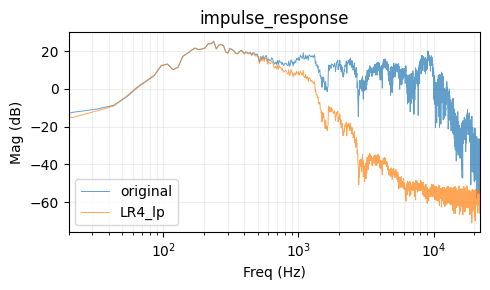

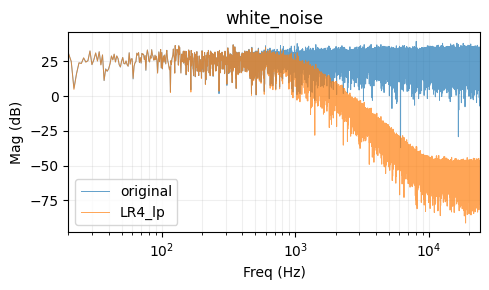

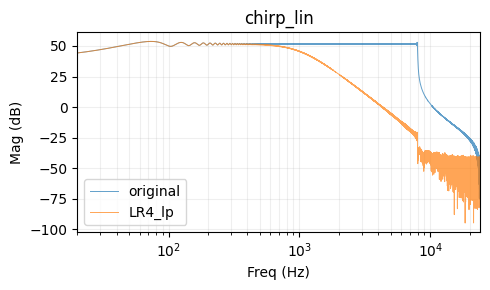

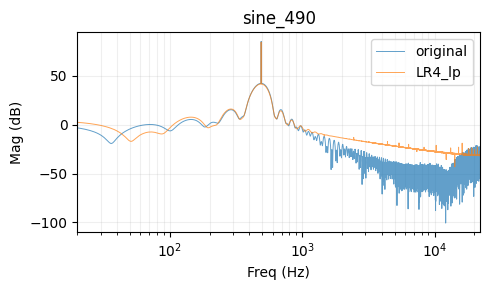

In [12]:
output = Apply_LR4(audios, fc = 1000, fs = 48000, kind = "lp")
overlay_spectra("LR4_lp", output, scale = "log")

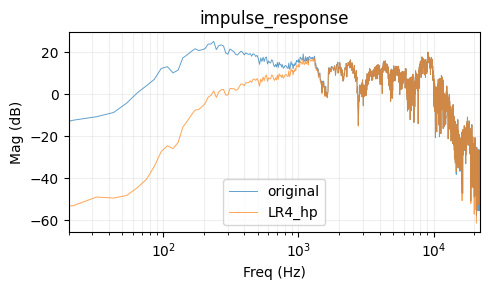

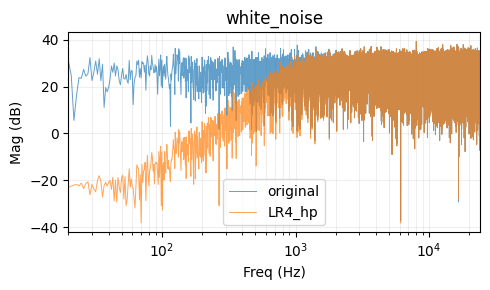

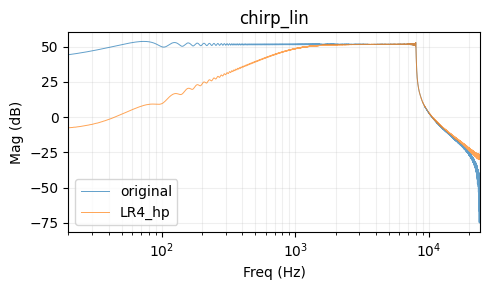

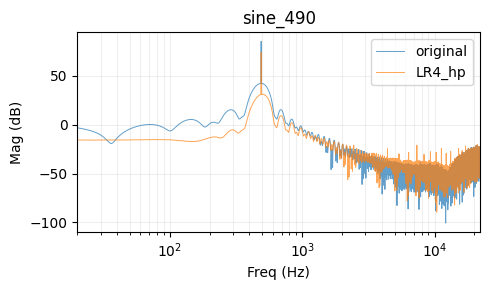

In [13]:
output = Apply_LR4(audios, fc = 1000, fs = 48000, kind = "hp")
overlay_spectra("LR4_hp", output, scale = "log")

### Delay/Echo

$y[n] = x[n] + g * y[n - D]$
- Small `D`: comb filter, coloration
- Larger `D`: more discrete repeat
- `g` closer to 0: high decay
- `g` closer to 1: small decay (longer)

In [14]:
def comb_delay(audios, D: int, g: float) -> dict:
  """
  calculate the number of repeats needed
  D: delay in samples
  """
  assert abs(g) < 1, f"g={g} will produce an unstable filter"

  output = {}
  for name, audio in audios.items():
      x, sr = sf.read(audio)
      b = np.array([1.0])
      a = np.zeros(D + 1)
      a[0] = 1
      a[D] = -g

      threshold_db = -60
      n_repeats_needed = int(np.ceil(threshold_db / (20 * np.log10(abs(g)))))
      pad_length = D * n_repeats_needed

      x_padded = np.concatenate([x, np.zeros(pad_length)])

      y = scipy.signal.lfilter(b, a, x_padded)

      sf.write(f"{name}_delayed.wav", y, sr)
      output[name] = (audio, f"{name}_delayed.wav")

  return output

In [15]:
delay_seconds = 300 / 1000
fs = 48000
D = int(round(delay_seconds * fs))
g = 0.5
test_audio = {"impulse_response": impulse_response}
output = comb_delay(test_audio, D, g)

impulse_response — original


impulse_response — Delay


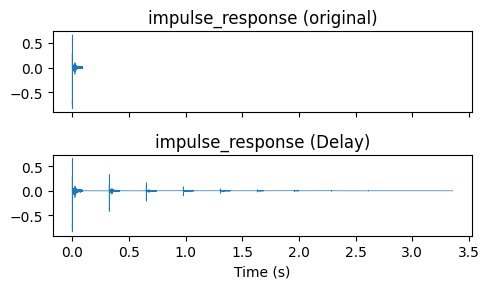

In [16]:
plot_audios("Delay", output)

### Reverb

sum of variable parallel combs
- $y[n] = x[n] + g * y[n - D]$

pass them in series through Allpass filters
- $y[n] = -g * x[n] + x[n - D] +g* y[n-D]$

In [17]:
def comb_filter(x, D, g):
    b = np.array([1.0])
    a = np.zeros(D + 1)
    a[0] = 1
    a[D] = -g
    return scipy.signal.lfilter(b, a, x)

def allpass_filter(x, D, g):
    b = np.zeros(D + 1)
    b[0] = -g
    b[D] = 1
    a = np.zeros(D + 1)
    a[0] = 1
    a[D] = -g
    return scipy.signal.lfilter(b, a, x)

def schroeder_reverb(audios, comb_delays_ms, comb_T60, allpass_delays_ms, allpass_g):
  output = {}
  for name, audio in audios.items():
    x, sr = sf.read(audio)
    threshold_db = -60
    max_D = int(round(max(comb_delays_ms) / 1000 * sr))
    g_max = 10 ** (threshold_db / 20 / ( (max(comb_delays_ms)/1000*sr) / (comb_T60*sr) ))
    pad_length = int(comb_T60 * sr)
    x_padded = np.concatenate([x, np.zeros(pad_length)])

    comb_sum = np.zeros_like(x_padded)
    for delay_ms in comb_delays_ms:
      D = int(round(delay_ms / 1000 * sr))
      g = 10 ** (-3 * D / (sr * comb_T60))
      y = comb_filter(x_padded, D, g)
      comb_sum += y

    out = comb_sum
    for delay_ms in allpass_delays_ms:
      D = int(round(delay_ms / 1000 * sr))
      out = allpass_filter(out, D, allpass_g)

    peak = np.max(np.abs(out))
    if peak > 1.0:
        out = out / peak * 0.99

    sf.write(f"{name}_reverbed.wav", out, sr)
    output[name] = (audio, f"{name}_reverbed.wav")

  return output

In [18]:
comb_delays_ms = [30 + i*5 for i in range(10)]
allpass_delays_ms = [5.0, 2]
allpass_g = 0.7
comb_T60 = 10.0
piano = {"piano": "/content/sms-tools-materials/sounds/sax-phrase-short.wav"}
output = schroeder_reverb(piano, comb_delays_ms, comb_T60, allpass_delays_ms, allpass_g)

piano — original


piano — Reverb!!!


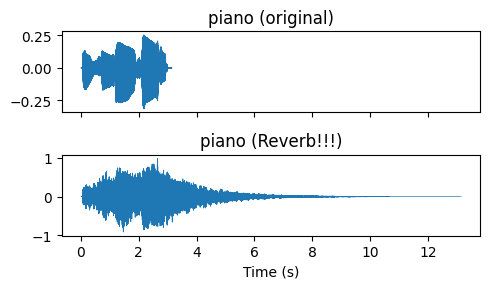

In [19]:
plot_audios("Reverb!!!", output)